In [20]:
import precice
import deepxde as dde
import numpy as np

# pde setup
from pde_geom import *
from net import *

precice_config = '../precice-config.xml'
solver_process_index = 0
solver_process_size = 1

participant_name = "Feedback"
mesh_name = "Feedback-Mesh"
participant = precice.Participant(participant_name, precice_config, solver_process_index, solver_process_size)

In [21]:
data = define_pde(geom, navier_stokes_pde, loss_terms)
model = dde.Model(data, net)

model.compile(
    "adam",
    lr=lr,
    loss_weights=loss_weights
)

# # Load  trained model
# model_path = "navier_stokes_channel_obstacle_model-600.pt"

# if not os.path.exists(model_path):
#     print(f"Error: Model file {model_path} not found!")
#     sys.exit(1)
# model.restore(save_path=model_path, verbose=1)

Compiling model...
'compile' took 0.000159 s



In [22]:
def model_predict(x_mesh, y_mesh, time=0.0):
    n_points_mesh = len(x_mesh.flatten())
    t_values_mesh = np.full(n_points_mesh, time)
    
    # Input to model: (x, y, t)
    points_to_predict = np.vstack((x_mesh.flatten(), y_mesh.flatten(), t_values_mesh)).T
    
    # Model predicts (u, v, p)
    predictions = model.predict(points_to_predict)
    
    u_pred = predictions[:, 0].reshape(x_mesh.shape)
    v_pred = predictions[:, 1].reshape(x_mesh.shape)
    p_pred = predictions[:, 2].reshape(x_mesh.shape)

    Velocity = np.column_stack([u_pred.flatten(), v_pred.flatten()])
    Pressure = p_pred.flatten()
    
    return Velocity, Pressure

In [23]:
# should match openfoam mesh
x_min, x_max = 0.0, domain_length
y_min, y_max = 0.0, domain_width
nx, ny = 60, 20

x_centers = np.linspace(x_min + (x_max - x_min)/(2*nx), x_max - (x_max - x_min)/(2*nx), nx)
y_centers = np.linspace(y_min + (y_max - y_min)/(2*ny), y_max - (y_max - y_min)/(2*ny), ny)

X_grid, Y_grid = np.meshgrid(x_centers, y_centers)
coordinates_precice = np.vstack([X_grid.flatten(), Y_grid.flatten()]).T

vertex_ids_precice = participant.set_mesh_vertices(mesh_name, coordinates_precice)

Velocity, Pressure = model_predict(X_grid, Y_grid, time=0.0)

participant.initialize()
time = 0.0

In [24]:
dt_precice = participant.get_max_time_step_size()

In [25]:
V_dataset = []
P_dataset = []
T_dataset = []

In [26]:
velocity_buffer = np.zeros((len(vertex_ids_precice)))

In [27]:
participant.read_data

<bound method Participant.read_data of <cyprecice.Participant object at 0x7af2d155cc90>>

In [28]:
while participant.is_coupling_ongoing():
    
    time += dt_precice
        
    Velocity_ground_truth = participant.read_data(mesh_name, "Velocity", vertex_ids_precice, 0)
    # Pressure_ground_truth = participant.read_data(mesh_name, "Pressure", vertex_ids_precice, 0)

    print(f"Time: {time:.3f}, dt_precice: {dt_precice:.3f}")

    V_dataset.append(np.copy(Velocity_ground_truth))
    # P_dataset.append(np.copy(Pressure_ground_truth))
    T_dataset.append(time)

    participant.advance(dt_precice)

    dt_precice = participant.get_max_time_step_size()
    
participant.finalize()
print("preCICE coupling finished.")

Time: 0.005, dt_precice: 0.005
Time: 0.010, dt_precice: 0.005
Time: 0.015, dt_precice: 0.005
Time: 0.020, dt_precice: 0.005
Time: 0.025, dt_precice: 0.005
Time: 0.030, dt_precice: 0.005
Time: 0.035, dt_precice: 0.005
Time: 0.040, dt_precice: 0.005
Time: 0.045, dt_precice: 0.005
Time: 0.050, dt_precice: 0.005
Time: 0.055, dt_precice: 0.005
Time: 0.060, dt_precice: 0.005
Time: 0.065, dt_precice: 0.005
Time: 0.070, dt_precice: 0.005
Time: 0.075, dt_precice: 0.005
Time: 0.080, dt_precice: 0.005
Time: 0.085, dt_precice: 0.005
Time: 0.090, dt_precice: 0.005
Time: 0.095, dt_precice: 0.005
Time: 0.100, dt_precice: 0.005
Time: 0.105, dt_precice: 0.005
Time: 0.110, dt_precice: 0.005
Time: 0.115, dt_precice: 0.005
Time: 0.120, dt_precice: 0.005
Time: 0.125, dt_precice: 0.005
Time: 0.130, dt_precice: 0.005
Time: 0.135, dt_precice: 0.005
Time: 0.140, dt_precice: 0.005
Time: 0.145, dt_precice: 0.005
Time: 0.150, dt_precice: 0.005
Time: 0.155, dt_precice: 0.005
Time: 0.160, dt_precice: 0.005
Time: 0.

In [35]:
dt_precice = 0.005

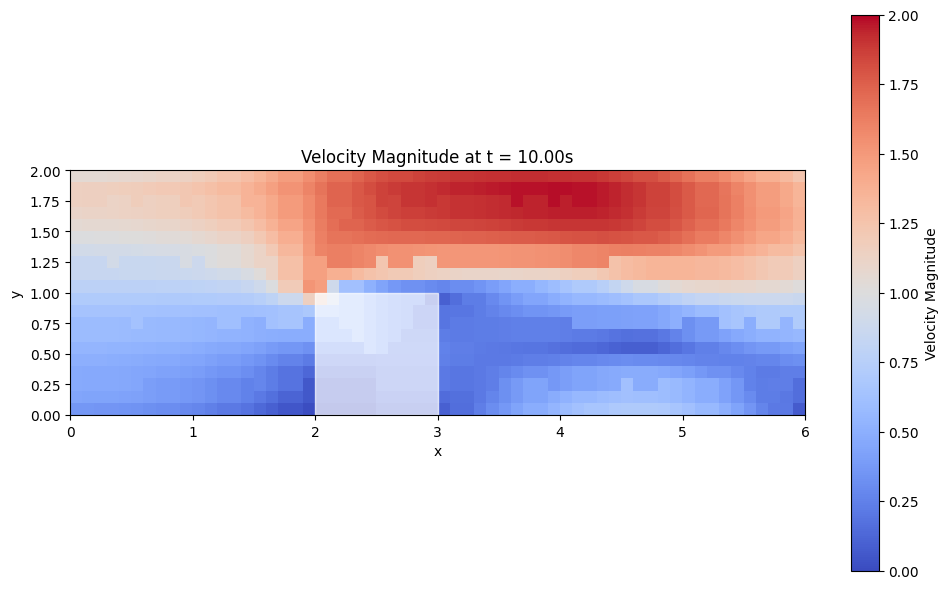

In [37]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fps = 1//dt_precice
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Extract the velocity magnitude for visualization
def compute_velocity_magnitude(velocity_field):
    reshaped = velocity_field.reshape((ny, nx, 2))
    u = reshaped[:, :, 0]
    v = reshaped[:, :, 1]
    return np.sqrt(u**2 + v**2)

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    velocity_mag = compute_velocity_magnitude(V_dataset[frame])
    im = ax.imshow(velocity_mag, cmap='coolwarm', origin='lower', 
                   extent=(x_min, x_max, y_min, y_max),
                   vmin=0, vmax=2)  # Consistent color range
    
    # Add obstacle representation
    ax.add_patch(plt.Rectangle((obstacle_x0, obstacle_y0), 
                              obstacle_x1-obstacle_x0, 
                              obstacle_y1-obstacle_y0,
                              color='white', alpha=0.7))
    
    ax.set_title(f'Velocity Magnitude at t = {T_dataset[frame]:.2f}s')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    return im,

# Create the animation
ani = FuncAnimation(fig, update, frames=len(V_dataset), 
                    interval=50, blit=True)

# Add colorbar
cbar = plt.colorbar(update(0)[0])
cbar.set_label('Velocity Magnitude')

plt.tight_layout()

ani.save('velocity_magnitude_animation.mp4', writer='ffmpeg', fps=fps)

In [ ]:
!jupyter nbconvert --to script 'training-participant.ipynb'

[NbConvertApp] Converting notebook training-participant.ipynb to script
[NbConvertApp] Writing 4128 bytes to training-participant.py
